In [6]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/DIP/Model_Training/Groups_DataCropped')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
from PIL import Image
from pathlib import Path

In [ ]:
def load_dataset_improved(data_dir='/content/drive/MyDrive/DIP /Model Training/Groups_DataCropped', img_size=(224, 224)):
    images, labels = [], []
    data_path = Path(data_dir)

    for class_dir in data_path.iterdir():
        if class_dir.is_dir():
            label = class_dir.name
            for img_file in class_dir.glob('*'):
                if img_file.suffix.lower() in ['.jpg', '.jpeg', '.png', '.webp']:
                    try:
                        img = Image.open(img_file).convert('RGB').resize(img_size, Image.Resampling.LANCZOS)
                        images.append(np.array(img))
                        labels.append(label)
                    except:
                        pass

    return np.array(images), np.array(labels)

print("Loading dataset...")
X, y = load_dataset_improved()
print(f"Loaded {len(X)} images")

Loading dataset...
Loaded 11814 images


In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_val, y_train, y_val = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

X_train = tf.keras.applications.efficientnet.preprocess_input(X_train)
X_val = tf.keras.applications.efficientnet.preprocess_input(X_val)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")

Training set: (9451, 224, 224, 3)
Validation set: (2363, 224, 224, 3)


In [ ]:
datagen = ImageDataGenerator(
    rotation_range=8,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.05,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)
base = EfficientNetB0(weights='imagenet',include_top=False,input_shape=(224,224,3))
base.trainable = False
x = GlobalAveragePooling2D()(base.output)
x = Dropout(0.4)(x)
output = Dense(len(le.classes_),activation='softmax')(x)
model = Model(inputs=base.input,outputs=output)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,091,844 (15.61 MB)

 Trainable params: 42,273 (165.13 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
reduce_lr = ReduceLROnPlateau( monitor='val_accuracy',factor=0.3,patience=3,verbose=1,mode='max')

# Auto save best model
checkpoint = tf.keras.callbacks.ModelCheckpoint('/content/drive/MyDrive/DIP /Model Training/best_model.keras',monitor='val_accuracy',save_best_only=True,mode='max',verbose=1)

# Compile
model.compile(optimizer=tf.keras.optimizers.Adam(2e-3),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

print("Training phase 1: Frozen base layers...")

history = model.fit(datagen.flow(X_train,y_train,batch_size=16),
    validation_data=(X_val, y_val),
    epochs=20,
    callbacks=[
        reduce_lr,
        checkpoint
    ]
)

Training phase 1: Frozen base layers...
Epoch 1/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 804ms/step - accuracy: 0.2626 - loss: 2.7013
Epoch 1: val_accuracy improved from None to 0.65933, saving model to /content/drive/MyDrive/DIP handwritting/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DIP handwritting/best_model.keras
591/591 ━━━━━━━━━━━━━━━━━━━━ 630s 1s/step - accuracy: 0.3866 - loss: 2.2045 - val_accuracy: 0.6593 - val_loss: 1.4009 - learning_rate: 0.0020
Epoch 2/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 757ms/step - accuracy: 0.5761 - loss: 1.5017
Epoch 2: val_accuracy improved from 0.65933 to 0.68134, saving model to /content/drive/MyDrive/DIP handwritting/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DIP handwritting/best_model.keras
591/591 ━━━━━━━━━━━━━━━━━━━━ 561s 948ms/step - accuracy: 0.5903 - loss: 1.4423 - val_accuracy: 0.6813 - val_loss: 1.1268 - learning_rate: 0.0020
Epoch 3/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 761ms/step - ac

In [ ]:
model.save('/content/drive/MyDrive/DIP /Model Training/phase1_model.keras')

In [ ]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/DIP /Model Training/phase1_model.keras')



In [ ]:
loss, acc = model.evaluate(X_val, y_val)
print(acc)

### phase2 model


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen_ft = ImageDataGenerator(
    rotation_range=3,
    zoom_range=0.05,
    width_shift_range=0.02,
    height_shift_range=0.02,
    fill_mode='nearest'
)

In [ ]:
# Freeze all layers first
for layer in model.layers:
    layer.trainable = False


# Unfreeze last 40 layers
for layer in model.layers[-40:]:
    layer.trainable = True


# Check trainable layers
for i, layer in enumerate(model.layers[-40:]):
    print(i, layer.name, layer.trainable)

0 block6c_se_expand True
1 block6c_se_excite True
2 block6c_project_conv True
3 block6c_project_bn True
4 block6c_drop True
5 block6c_add True
6 block6d_expand_conv True
7 block6d_expand_bn True
8 block6d_expand_activation True
9 block6d_dwconv True
10 block6d_bn True
11 block6d_activation True
12 block6d_se_squeeze True
13 block6d_se_reshape True
14 block6d_se_reduce True
15 block6d_se_expand True
16 block6d_se_excite True
17 block6d_project_conv True
18 block6d_project_bn True
19 block6d_drop True
20 block6d_add True
21 block7a_expand_conv True
22 block7a_expand_bn True
23 block7a_expand_activation True
24 block7a_dwconv True
25 block7a_bn True
26 block7a_activation True
27 block7a_se_squeeze True
28 block7a_se_reshape True
29 block7a_se_reduce True
30 block7a_se_expand True
31 block7a_se_excite True
32 block7a_project_conv True
33 block7a_project_bn True
34 top_conv True
35 top_bn True
36 top_activation True
37 global_average_pooling2d_1 True
38 dropout True
39 dense True


In [ ]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.2,
    patience=2,
    verbose=1,
    mode='max',
    min_lr=1e-7
)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

checkpoint_ft = ModelCheckpoint(
    "/content/drive/MyDrive/DIP handwritting/best_finetune.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)


model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


print("Phase 2 Fine-tuning...")


history_ft = model.fit(
    datagen_ft.flow(
        X_train,
        y_train,
        batch_size=16
    ),
    validation_data=(
        X_val,
        y_val
    ),
    epochs=10,
    callbacks=[
        reduce_lr,
        checkpoint_ft
    ]
)

Phase 2 Fine-tuning...
Epoch 1/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4862 - loss: 1.9628
Epoch 1: val_accuracy improved from None to 0.73085, saving model to /content/drive/MyDrive/DIP handwritting/best_finetune.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DIP handwritting/best_finetune.keras
591/591 ━━━━━━━━━━━━━━━━━━━━ 1288s 2s/step - accuracy: 0.5283 - loss: 1.7186 - val_accuracy: 0.7309 - val_loss: 0.8635 - learning_rate: 1.0000e-05
Epoch 2/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6305 - loss: 1.2127
Epoch 2: val_accuracy improved from 0.73085 to 0.78798, saving model to /content/drive/MyDrive/DIP handwritting/best_finetune.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DIP handwritting/best_finetune.keras
591/591 ━━━━━━━━━━━━━━━━━━━━ 1240s 2s/step - accuracy: 0.6400 - loss: 1.1683 - val_accuracy: 0.7880 - val_loss: 0.6658 - learning_rate: 1.0000e-05
Epoch 3/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy:

In [ ]:
model.save('/content/drive/MyDrive/DIP/Model_Training/phase2_model.keras')

In [8]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/DIP/Model_Training/phase2_model.keras')



### LabelEncoder

In [ ]:
from tensorflow.keras.models import load_model
import numpy as np
import pickle
from sklearn.preprocessing import LabelEncoder

# =========================
# 1. LOAD MODEL
# =========================
model = load_model('/content/drive/MyDrive/DIP /Model Training/phase2_model.keras')

# =========================
# 2. EVALUATE MODEL
# =========================
loss, acc = model.evaluate(X_val, y_val)
print("Validation Accuracy:", acc)


# =========================
# 3. SAVE LABEL ENCODER (IMPORTANT)
# =========================
le = LabelEncoder()
le.fit(y)   # IMPORTANT: original labels (not y_encoded)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

print("Label encoder saved successfully!")


# =========================
# 4. TEST SINGLE PREDICTION (OPTIONAL CHECK)
# =========================
i = 0
sample = X_val[i]

pred = model.predict(np.expand_dims(sample, axis=0))
index = np.argmax(pred)

label = le.inverse_transform([index])[0]
confidence = np.max(pred) * 100

print("Predicted:", label)
print("Confidence:", confidence)

74/74 ━━━━━━━━━━━━━━━━━━━━ 215s 3s/step - accuracy: 0.9048 - loss: 0.3349
Validation Accuracy: 0.9047820568084717
Label encoder saved successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted: r2_c4
Confidence: 88.13963


In [ ]:
import pickle

save_path = "/content/drive/MyDrive/DIP /Model Test/label_encoder.pkl"
with open(save_path, "wb") as f:
    pickle.dump(le, f)
print("Saved to Drive!")

Saved to Drive!


In [ ]:
print(type(le))
print(le.classes_)

<class 'sklearn.preprocessing._label.LabelEncoder'>
['r0_c0' 'r0_c1' 'r0_c2' 'r0_c3' 'r0_c4' 'r1_c0' 'r1_c1' 'r1_c2' 'r1_c3'
 'r1_c4' 'r2_c0' 'r2_c1' 'r2_c2' 'r2_c3' 'r2_c4' 'r3_c0' 'r3_c1' 'r3_c2'
 'r3_c3' 'r3_c4' 'r4_c0' 'r4_c1' 'r4_c2' 'r4_c3' 'r4_c4' 'r5_c0' 'r5_c1'
 'r5_c2' 'r5_c3' 'r5_c4' 'r6_c1' 'r6_c2' 'r6_c3']


### Model test

In [ ]:
import cv2
import numpy as np
import tensorflow as tf

img = cv2.imread('/content/drive/MyDrive/DIP /Computer Vision OCR/debug_0.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, bw = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
bw = cv2.cvtColor(bw, cv2.COLOR_GRAY2RGB)
bw = cv2.resize(bw, (224,224))
bw = np.expand_dims(bw, axis=0)
bw = tf.keras.applications.efficientnet.preprocess_input(bw)
predictions = model.predict(bw)
mm_classes = [
    'က','ခ','ဂ','ဃ','င',
    'စ','ဆ','ဇ','ဈ','ည',
    'ဋ','ဌ','ဍ','ဎ','ဏ',
    'တ','ထ','ဒ','ဓ','န',
    'ပ','ဖ','ဗ','ဘ','မ',
    'ယ','ရ','လ','ဝ','သ',
    'ဟ','ဠ','အ'
]

pred_class = np.argmax(predictions[0])
confidence = np.max(predictions[0])*100
print(
    f"This image most likely belongs to {mm_classes[pred_class]} "
    f"with a {confidence:.2f}% confidence."
)

# Top 3 predictions
top3 = np.argsort(predictions[0])[-3:][::-1]

print("\nTop 3 Predictions:")
for idx in top3:
    print(f"{mm_classes[idx]} : {predictions[0][idx]*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
This image most likely belongs to ရ with a 31.86% confidence.

Top 3 Predictions:
ရ : 31.86%
န : 19.92%
ဏ : 16.71%


In [9]:
import os
import cv2
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

root_folder = "/content/drive/MyDrive/DIP/Model_Test/testgroups_croppedimages"

mm_classes = [
    'က','ခ','ဂ','ဃ','င',
    'စ','ဆ','ဇ','ဈ','ည',
    'ဋ','ဌ','ဍ','ဎ','ဏ',
    'တ','ထ','ဒ','ဓ','န',
    'ပ','ဖ','ဗ','ဘ','မ',
    'ယ','ရ','လ','ဝ','သ',
    'ဟ','ဠ','အ'
]

results = []

for true_label in os.listdir(root_folder):

    class_folder = os.path.join(root_folder, true_label)

    if not os.path.isdir(class_folder):
        continue

    print(f"\n===== Folder : {true_label} =====")

    for filename in os.listdir(class_folder):

        image_path = os.path.join(class_folder, filename)

        img = cv2.imread(image_path)

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        _, bw = cv2.threshold(gray,127,255,cv2.THRESH_BINARY)
        bw = cv2.cvtColor(bw, cv2.COLOR_GRAY2RGB)
        bw = cv2.resize(bw,(224,224))

        bw = np.expand_dims(bw,axis=0)
        bw = tf.keras.applications.efficientnet.preprocess_input(bw)

        predictions = model.predict(bw,verbose=0)

        pred_class = np.argmax(predictions[0])
        confidence = np.max(predictions[0])*100

        pred_label = mm_classes[pred_class]

        print(f"{filename} --> {pred_label} ({confidence:.2f}%)")

        # Save result
        results.append({
            "True Label": true_label,
            "File Name": filename,
            "Predicted Label": pred_label,
            "Confidence (%)": round(confidence,2)
        })


===== Folder : r6_c3 =====
t (1)_r6_c3.jpg --> အ (99.76%)
t (10)_r6_c3.jpg --> အ (98.27%)
t (11)_r6_c3.jpg --> အ (98.16%)
t (12)_r6_c3.jpg --> အ (99.89%)
t (13)_r6_c3.jpg --> အ (99.90%)
t (14)_r6_c3.jpg --> အ (98.02%)
t (15)_r6_c3.jpg --> အ (93.11%)
t (16)_r6_c3.jpg --> အ (99.98%)
t (18)_r6_c3.jpg --> အ (88.07%)
t (19)_r6_c3.jpg --> အ (97.81%)
t (2)_r6_c3.jpg --> အ (99.89%)
t (20)_r6_c3.jpg --> အ (97.63%)
t (21)_r6_c3.jpg --> အ (99.87%)
t (3)_r6_c3.jpg --> အ (98.88%)
t (4)_r6_c3.jpg --> အ (99.96%)
t (5)_r6_c3.jpg --> အ (99.07%)
t (6)_r6_c3.jpg --> အ (99.94%)
t (7)_r6_c3.jpg --> အ (97.16%)
t (8)_r6_c3.jpg --> ဘ (60.56%)
t (9)_r6_c3.jpg --> အ (99.89%)
t (17)_r6_c3.jpg --> အ (99.37%)

===== Folder : r5_c4 =====
t (1)_r5_c4.jpg --> ဘ (58.94%)
t (10)_r5_c4.jpg --> သ (64.15%)
t (11)_r5_c4.jpg --> သ (94.94%)
t (12)_r5_c4.jpg --> ဟ (36.59%)
t (13)_r5_c4.jpg --> လ (32.97%)
t (14)_r5_c4.jpg --> သ (50.17%)
t (15)_r5_c4.jpg --> ဘ (76.57%)
t (16)_r5_c4.jpg --> သ (42.22%)
t (18)_r5_c4.jpg --> သ (71

### save excel

### save excel

In [10]:
df = pd.DataFrame(results)

excel_path = "/content/drive/MyDrive/DIP/Model_Test/prediction_results.xlsx"

df.to_excel(excel_path,index=False)

print("\nSaved :",excel_path)


Saved : /content/drive/MyDrive/DIP/Model_Test/prediction_results.xlsx


Bar chart saved to: /content/drive/MyDrive/DIP/Model_Test/correct_predictions_bar_chart.png


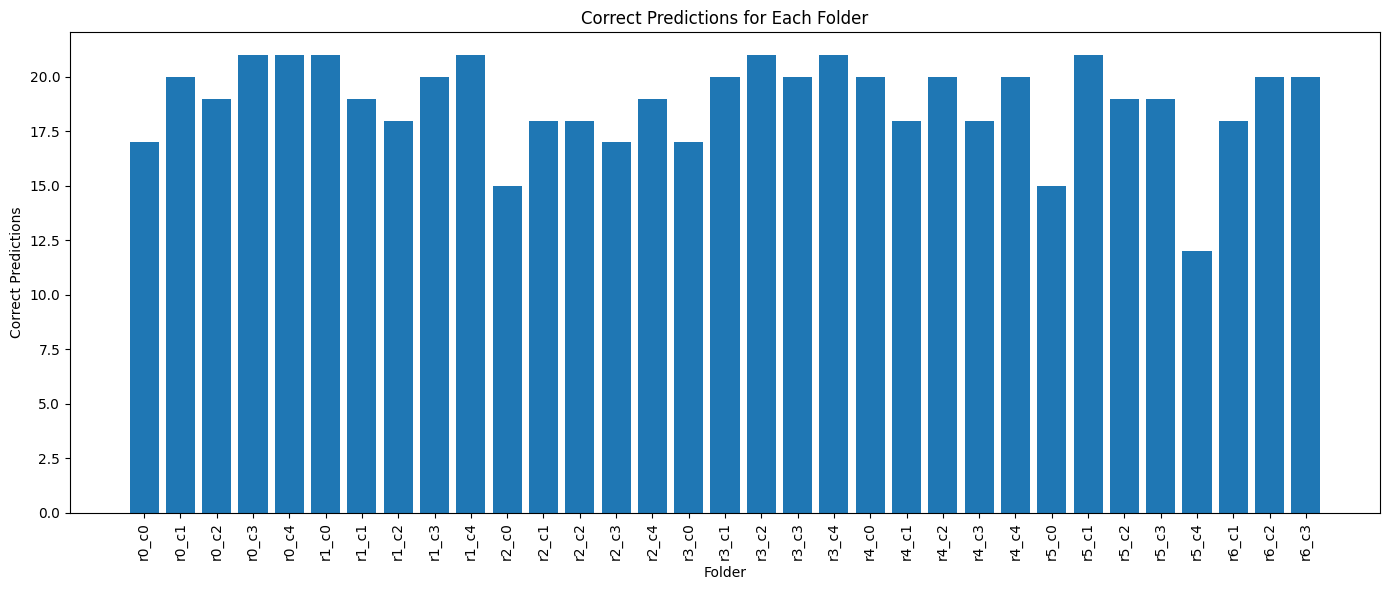

In [11]:
import matplotlib.pyplot as plt

folder_to_label = {
    "r0_c0":"က",
    "r0_c1":"ခ",
    "r0_c2":"ဂ",
    "r0_c3":"ဃ",
    "r0_c4":"င",

    "r1_c0":"စ",
    "r1_c1":"ဆ",
    "r1_c2":"ဇ",
    "r1_c3":"ဈ",
    "r1_c4":"ည",

    "r2_c0":"ဋ",
    "r2_c1":"ဌ",
    "r2_c2":"ဍ",
    "r2_c3":"ဎ",
    "r2_c4":"ဏ",

    "r3_c0":"တ",
    "r3_c1":"ထ",
    "r3_c2":"ဒ",
    "r3_c3":"ဓ",
    "r3_c4":"န",

    "r4_c0":"ပ",
    "r4_c1":"ဖ",
    "r4_c2":"ဗ",
    "r4_c3":"ဘ",
    "r4_c4":"မ",

    "r5_c0":"ယ",
    "r5_c1":"ရ",
    "r5_c2":"လ",
    "r5_c3":"ဝ",
    "r5_c4":"သ",

    "r6_c1":"ဟ",
    "r6_c2":"ဠ",
    "r6_c3":"အ"
}

df["Correct"] = df.apply(
    lambda x: folder_to_label[x["True Label"]] == x["Predicted Label"],
    axis=1
)

correct_count = df[df["Correct"]].groupby("True Label").size()



plt.figure(figsize=(14,6))

plt.bar(correct_count.index, correct_count.values)

plt.xlabel("Folder")
plt.ylabel("Correct Predictions")
plt.title("Correct Predictions for Each Folder")

plt.xticks(rotation=90)

plt.tight_layout()

chart_path = "/content/drive/MyDrive/DIP/Model_Test/correct_predictions_bar_chart.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

print("Bar chart saved to:", chart_path)

plt.show()

plt.close()